# Lab cleanup Navigators


_Imports and Helpers_


In [1]:
from navigator_types import SystematicNavigator
from navigators import BousPath, SpiralPath
import matplotlib.pyplot as plt
import utils as ut
import cv2


def show_imgs(imgs, labels):
    n = len(imgs)
    fig, ax = plt.subplots(1, n, figsize=(6*n, 6))

    if n == 1:
        ax = [ax]

    for i in range(n):
        img = cv2.normalize(imgs[i], None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
        ax[i].imshow(img, cmap="gray")
        ax[i].set_title(labels[i])
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()

ModuleNotFoundError: No module named 'mirte_lc_nav2'

## Setup

In order to demonstrate the different navigators, a map must first be loaded into the notebook. \
We use a map provided by the [mirte navigation](https://github.com/MartijnWisse/mirte_navigation) ros2 package


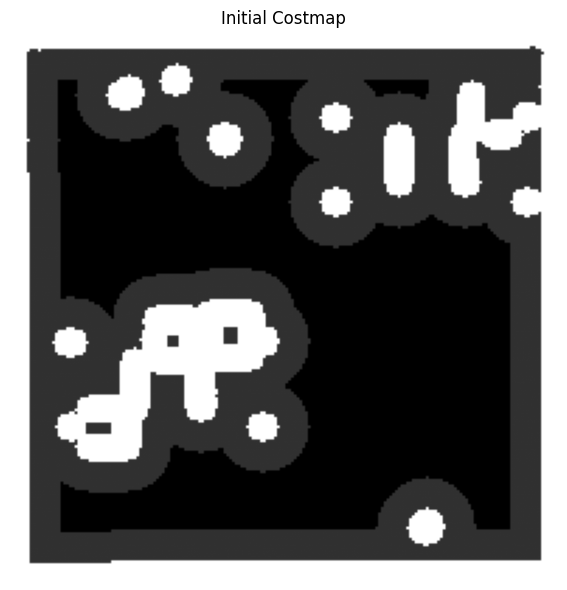

In [ ]:
path = "maps/lc_costmap.pgm"
map_img = cv2.bitwise_not(cv2.imread(path, cv2.IMREAD_UNCHANGED))
show_imgs([map_img], ['Initial Costmap'])

## Systematic Navigator

Each defined navigator is a derived class of `SystematicNavigator`, a metaclass encompassing all navigators \
that plan coverage paths over the whole free space area. Standard for the derived classes is that they \
update their internal map and as a result plan a path over this map.

```update_map()``` first takes the costmap and, given a threshold, sets the free space to [0, 0, 0] and occupied space [255, 255, 255]. \
It then uses ```opencv.findContours()``` to find the free space boundaries and saves these as contours.



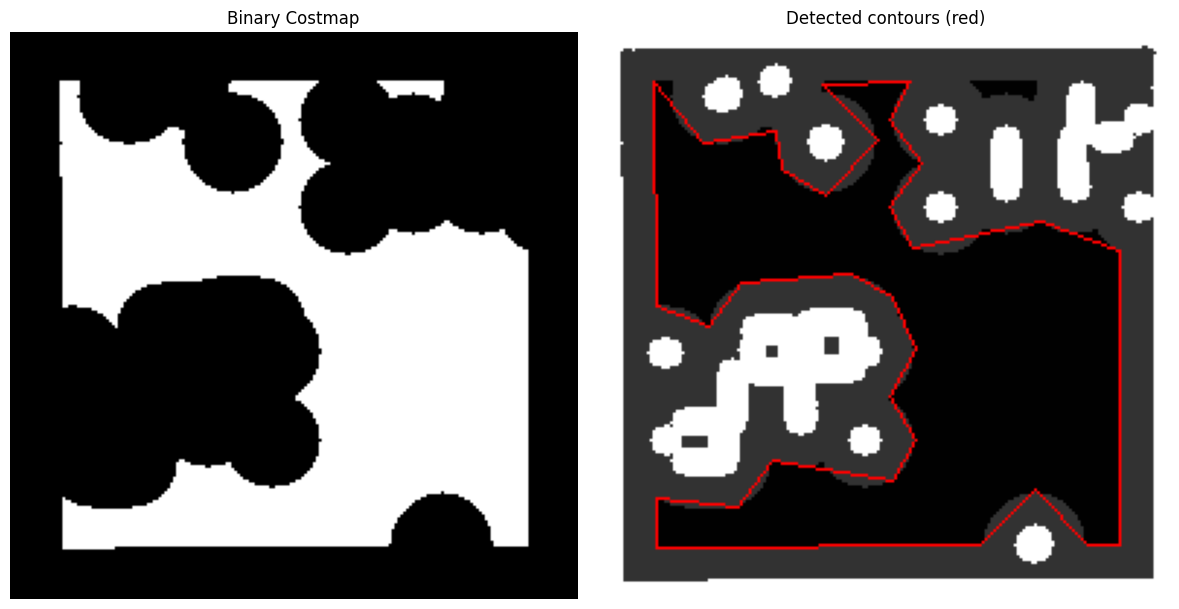

In [ ]:
navigator = SystematicNavigator()

navigator.update_map(map_img)
contours = navigator.contours

color_img = cv2.cvtColor(map_img, cv2.COLOR_GRAY2RGB)
contour_img = cv2.drawContours(color_img, contours, -1, (255, 0, 0), 1)

show_imgs([navigator.binary_costmap, contour_img], 
         ['Binary Costmap', 'Detected contours (red)'])

## BousPath
The first navigator that will be covered is a Boustropedon based Coverage planner. \
This navigator plans in two steps:
- Decomposition
- Swath Generation

### Boustropedon Cellular Decomposition

0: 32 points
Performing Decomposition
map decomposed, publishing decomposition


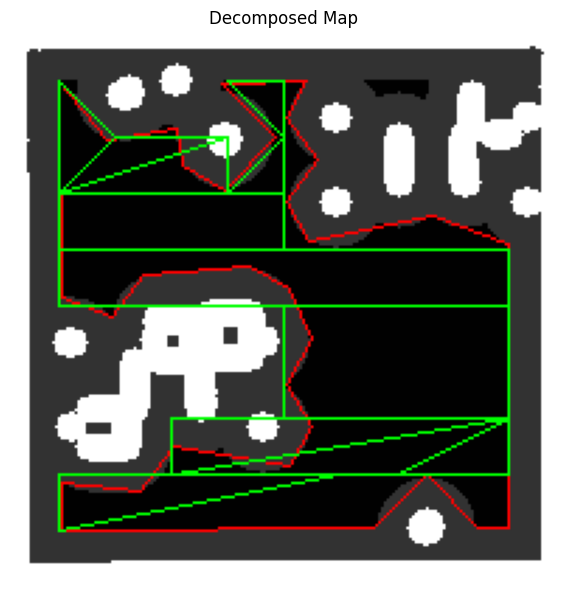

In [ ]:
# Update internal map
navigator = BousPath()
navigator.update_map(map_img, generate=False, decompose=False)

# Perform Boustropethan Celular Decomposition
navigator.bcd()
pixel_cells = [navigator.world_to_pixel(poly) for poly in navigator.raw_cells]

decomp_img = cv2.drawContours(color_img, pixel_cells, -1, (0, 255, 0), 1)
show_imgs(
    [decomp_img],
    ['Decomposed Map']
)


### Boustrophedon Path Generation

Number of cells: 15
generating path
generating full trajectory


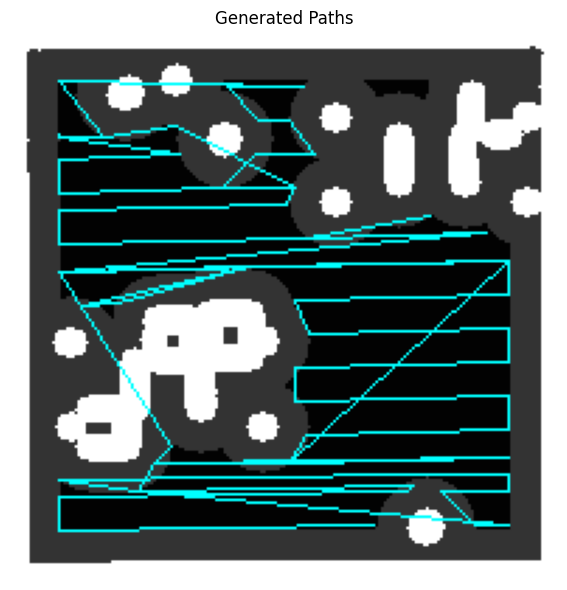

In [ ]:
navigator.bous_path()
paths = navigator.resultant_path

swath_img = cv2.cvtColor(map_img, cv2.COLOR_GRAY2RGB)

for path in paths:
    swath_img = cv2.polylines(
        swath_img,
        [path],
        isClosed=False,
        color=(0, 255, 255),
        thickness=1
    )
show_imgs(
    [swath_img],
    ['Generated Paths']
)
